# train.ipynb

**Langkah 3: pelatihan.**

Membangun, mengompilasi, dan melatih DeepLabV3+ serta memplot riwayat pelatihan. Notebook ini bergantung pada `metrics.ipynb`, `model.ipynb`, dan `data.ipynb`; sel di bawah memuatnya dengan `%run`.

Sorotan: mixed precision (Tensor Cores), 50 epoch dengan EarlyStopping dan pemulihan bobot terbaik, metrik pelatihan TF murni, dan warmup dua fase (aktif default, `FREEZE_BACKBONE_EPOCHS = 3`) untuk stabilitas di bawah mixed_float16.

> **Runtime.** Melatih semua 50 epoch pada ~7.200 pasangan augmentasi dengan batch 2 adalah pekerjaan GPU. Sel pelatihan hanya melatih jika belum ada checkpoint; setel `TRAIN = True` untuk memaksanya.

In [1]:
# Muat modul yang dibutuhkan notebook ini.
# _DEMO=False menekan sel demo/self-check mereka selama %run.
_DEMO = False
%run metrics.ipynb
%run model.ipynb
%run data.ipynb
_DEMO = True

In [2]:
import os
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")
os.environ.setdefault("TF_XLA_FLAGS", "--tf_xla_enable_xla_devices=false")

import numpy as np
import pandas as pd
import tensorflow as tf

### Pengaturan lingkungan

Aktifkan mixed precision (sebelum membangun model apa pun), setel seed, dan aktifkan memory growth GPU agar TF tidak mempra-alokasikan seluruh 6 GB.

In [3]:
def enable_mixed_precision():
    """
    Aktifkan komputasi float16 (Tensor Cores pada GPU RTX). Mencoba API modern,
    fallback ke API experimental lama untuk TF < 2.11.
    """
    try:
        from tensorflow.keras import mixed_precision
        mixed_precision.set_global_policy("mixed_float16")
    except AttributeError:
        from tensorflow.keras.mixed_precision import experimental as mp  # type: ignore
        mp.set_policy(mp.Policy("mixed_float16"))
    print("[INFO] Mixed precision (float16) diaktifkan.")


def configure_gpu():
    """Aktifkan memory growth agar TF tidak mempra-alokasikan seluruh 6 GB sekaligus."""
    gpus = tf.config.list_physical_devices("GPU")
    for gpu in gpus:
        try:
            tf.config.experimental.set_memory_growth(gpu, True)
        except RuntimeError:
            pass  # sudah diinisialisasi
    if gpus:
        print(f"[GPU]  {len(gpus)} GPU terdeteksi, memory growth diaktifkan.")
    else:
        print("[GPU]  Tidak ada GPU terdeteksi, pelatihan di CPU (lambat).")
    return gpus


def setup_environment():
    """Satu panggilan untuk mengaktifkan mixed precision, menyetel seed, dan mengonfigurasi GPU."""
    enable_mixed_precision()
    np.random.seed(42)
    tf.random.set_seed(42)
    return configure_gpu()

### Kompilasi dan callback

AdamW dengan gradient clipping, loss kombinasi Dice+Focal dengan metrik TF murni, dan set callback standar (checkpoint, LR plateau, CSV log, early stop).

In [ ]:
def build_optimizer(lr):
    """AdamW dengan gradient clipping; fallback ke Adam pada TF lama."""
    try:
        return tf.keras.optimizers.AdamW(
            learning_rate=lr, weight_decay=1e-4, clipnorm=1.0
        )
    except AttributeError:
        print("[INFO] AdamW tidak tersedia; menggunakan Adam.")
        return tf.keras.optimizers.Adam(learning_rate=lr, clipnorm=1.0)  # type: ignore


def compile_model(model, lr=1e-4):
    """Kompilasi dengan loss kombinasi Dice+Focal dan metrik TF murni."""
    from tensorflow.keras.metrics import Recall, Precision  # type: ignore
    model.compile(
        loss=combined_loss,
        optimizer=build_optimizer(lr),
        metrics=[dice_coef, iou, Recall(name="recall"), Precision(name="precision")],
    )
    return model


def make_callbacks(model_path, csv_path, patience=10, use_tensorboard=True):
    """
    Set callback standar: checkpoint, LR plateau, CSV log, early stop.

    Memantau val_iou (mode="max"), bukan val_loss. iou/recall/precision men-
    threshold prediksi (`y_pred > 0.5`) sebelum dibandingkan, dan di TensorFlow
    perbandingan NaN selalu False - jadi satu batch yang forward pass-nya NaN
    (risiko nyata di bawah mixed_float16 pada training awal) hanya membuat
    batch itu dihitung salah, bukan meracuni rata-rata berjalan metrik untuk
    sisa epoch. val_loss/val_dice_coef sebaliknya memakai output mentah
    langsung, jadi satu batch NaN membuat val_loss NaN untuk SISA epoch itu
    dan seterusnya - ModelCheckpoint(monitor="val_loss") lalu tidak akan
    pernah melihat "peningkatan" dan tidak akan pernah menyimpan apa pun,
    bahkan ketika model sebenarnya sedang belajar dengan baik.
    """
    from tensorflow.keras.callbacks import (  # type: ignore
        ModelCheckpoint, CSVLogger, ReduceLROnPlateau, EarlyStopping, TensorBoard,
    )
    cbs = [
        ModelCheckpoint(model_path, monitor="val_iou", mode="max", verbose=1,
                        save_best_only=True),
        ReduceLROnPlateau(monitor="val_iou", mode="max", factor=0.1, patience=5,
                          min_lr=1e-7, verbose=1),
        CSVLogger(csv_path),
        EarlyStopping(monitor="val_iou", mode="max", patience=patience,
                      restore_best_weights=True, verbose=1),
    ]
    if use_tensorboard:
        cbs.append(TensorBoard(histogram_freq=1))
    return cbs


def _merge_histories(*histories):
    """Gabungkan beberapa dict Keras History.history menjadi satu dict berisi list."""
    merged = {}
    for h in histories:
        for k, v in h.items():
            merged.setdefault(k, []).extend(list(v))
    return merged

### Orkestrasi pelatihan

`run_training` menangani fase warmup opsional (backbone beku) diikuti fine-tuning penuh, dan mengembalikan model plus dict riwayat gabungan.

In [ ]:
def run_training(train_x, train_y, valid_x, valid_y,
                 batch_size=2, lr=1e-4, num_epochs=50,
                 freeze_backbone_epochs=0, weights="imagenet",
                 model_path=os.path.join("files", "model.h5"),
                 csv_path=os.path.join("files", "data.csv"),
                 patience=10, steps_per_epoch=None, validation_steps=None):
    """
    Bangun, kompilasi, dan latih model. Mengembalikan (model, dict_riwayat_gabungan).

    Jika freeze_backbone_epochs > 0, menjalankan fase warmup dengan backbone beku
    sebelum mencairkan dan melatih jaringan penuh. Dengan default 0 ini adalah
    eksekusi satu fase.

    steps_per_epoch : None | int
        Jika diberikan, setiap epoch dibatasi pada sejumlah batch ini (dataset
        train di-`repeat()` agar tidak kehabisan data) dan epoch berikutnya
        melanjutkan dari titik shuffle berikutnya. Ini membatasi waktu per-epoch
        di GPU laptop tanpa membuang sampel: seluruh ~40k pasangan tetap terlihat
        sepanjang run, hanya tersebar pada lebih banyak epoch. Dengan None,
        setiap epoch melihat seluruh dataset satu kali (perilaku lama).
    validation_steps : None | int
        Sama seperti steps_per_epoch tapi untuk data validasi. Tanpa ini, setiap
        epoch selalu mengevaluasi seluruh set validasi (567 pasangan) terlepas
        dari seberapa kecil steps_per_epoch, yang bisa mendominasi waktu run
        singkat (mis. smoke test). Setel ke angka kecil untuk uji cepat.
    """
    create_dir(os.path.dirname(model_path) or ".")

    train_ds = tf_dataset(train_x, train_y, batch=batch_size, shuffle=True, training=True)
    valid_ds = tf_dataset(valid_x, valid_y, batch=batch_size, shuffle=False, training=False)

    # Dengan steps_per_epoch, dataset train harus tak hingga (repeat) agar fit
    # tidak kehabisan batch sebelum mencapai jumlah step yang diminta.
    if steps_per_epoch:
        train_ds = train_ds.repeat()
        print(f"[TRAIN] steps_per_epoch={steps_per_epoch} "
              f"(~{steps_per_epoch * batch_size:,} gambar/epoch dari {len(train_x):,} pasangan)")
    if validation_steps:
        valid_ds = valid_ds.repeat()
        print(f"[TRAIN] validation_steps={validation_steps} "
              f"(~{validation_steps * batch_size:,} gambar validasi dari {len(valid_x):,} pasangan)")

    do_warmup = freeze_backbone_epochs and freeze_backbone_epochs > 0
    model = deeplabv3_plus((H, W, 3), weights=weights, freeze_backbone=bool(do_warmup))

    histories = []

    if do_warmup:
        print(f"\n[FASE 1] Warmup: backbone beku selama {freeze_backbone_epochs} epoch.")
        compile_model(model, lr=lr)
        print(f"[FASE 1] Parameter yang dapat dilatih: "
              f"{int(sum(tf.keras.backend.count_params(w) for w in model.trainable_weights)):,}")
        h1 = model.fit(
            train_ds, validation_data=valid_ds,
            epochs=freeze_backbone_epochs,
            steps_per_epoch=steps_per_epoch,
            validation_steps=validation_steps,
            callbacks=make_callbacks(model_path, csv_path.replace(".csv", "_warmup.csv"),
                                     patience=patience, use_tensorboard=False),
        )
        histories.append(h1.history)

        print("\n[FASE 2] Mencairkan backbone (BatchNorm tetap beku).")
        set_backbone_trainable(model, trainable=True, freeze_bn=True)
        compile_model(model, lr=lr)  # kompilasi ulang setelah mengubah trainability
        print(f"[FASE 2] Parameter yang dapat dilatih: "
              f"{int(sum(tf.keras.backend.count_params(w) for w in model.trainable_weights)):,}")
        remaining = max(1, num_epochs - freeze_backbone_epochs)
        h2 = model.fit(
            train_ds, validation_data=valid_ds,
            epochs=remaining,
            steps_per_epoch=steps_per_epoch,
            validation_steps=validation_steps,
            callbacks=make_callbacks(model_path, csv_path, patience=patience),
        )
        histories.append(h2.history)
    else:
        compile_model(model, lr=lr)
        print(f"[MODEL] Parameter: {model.count_params():,}")
        print(f"[TRAIN] batch={batch_size}, lr={lr}, epoch={num_epochs}")
        h = model.fit(
            train_ds, validation_data=valid_ds,
            epochs=num_epochs,
            steps_per_epoch=steps_per_epoch,
            validation_steps=validation_steps,
            callbacks=make_callbacks(model_path, csv_path, patience=patience),
        )
        histories.append(h.history)

    return model, _merge_histories(*histories)

### Plot riwayat pelatihan

In [6]:
def _find_col(columns, base, val=False):
    """Temukan kolom metrik (mungkin berakhiran) dari dict/CSV riwayat."""
    for c in columns:
        is_val = c.startswith("val")
        if base in c and is_val == val:
            return c
    return None


def plot_history(history, save_dir="plots", phase_boundary=None):
    """
    Plot loss, Dice, IoU, dan Recall (train vs validasi) plus jadwal
    learning-rate dari dict riwayat in-memory (riwayat gabungan dua fase berfungsi).
    Disimpan ke plots/05_training_history.png.
    """
    import matplotlib
    matplotlib.use("Agg")
    import matplotlib.pyplot as plt

    create_dir(save_dir)
    cols = list(history.keys())
    n_epochs = len(history.get("loss", []))
    if n_epochs == 0:
        print("[PERINGATAN] Riwayat kosong; tidak ada yang bisa diplot.")
        return
    epochs = range(1, n_epochs + 1)

    panels = [("loss", "Loss Kombinasi"), ("dice_coef", "Koefisien Dice"),
              ("iou", "IoU"), ("recall", "Recall")]
    has_lr = "lr" in cols or "learning_rate" in cols
    n_axes = len(panels) + (1 if has_lr else 0)
    ncol = 3
    nrow = int(np.ceil(n_axes / ncol))

    fig, axes = plt.subplots(nrow, ncol, figsize=(ncol * 5, nrow * 4))
    axes = np.array(axes).flatten()

    for ax, (key, title) in zip(axes, panels):
        tc = _find_col(cols, key, val=False)
        vc = _find_col(cols, key, val=True)
        if tc:
            ax.plot(epochs, history[tc], color="#2196F3", linewidth=2, label="Train")
        if vc:
            ax.plot(epochs, history[vc], color="#F44336", linewidth=2,
                    linestyle="--", label="Validasi")
        if phase_boundary:
            ax.axvline(phase_boundary + 0.5, color="green", linestyle=":",
                       linewidth=1.5, label="Pencairan")
        ax.set_title(title, fontsize=13, fontweight="bold")
        ax.set_xlabel("Epoch")
        ax.legend(fontsize=9)
        ax.grid(alpha=0.3)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    idx = len(panels)
    if has_lr:
        lr_key = "lr" if "lr" in cols else "learning_rate"
        axes[idx].plot(epochs, history[lr_key], color="#FF9800", linewidth=2)
        axes[idx].set_title("Learning Rate", fontsize=13, fontweight="bold")
        axes[idx].set_xlabel("Epoch")
        axes[idx].set_yscale("log")
        axes[idx].grid(alpha=0.3)
        axes[idx].spines["top"].set_visible(False)
        axes[idx].spines["right"].set_visible(False)
        idx += 1

    for j in range(idx, len(axes)):
        axes[j].axis("off")

    fig.suptitle("Riwayat Pelatihan - DeepLabV3+ (ResNet50)", fontsize=16, fontweight="bold")
    plt.tight_layout()
    out = os.path.join(save_dir, "05_training_history.png")
    plt.savefig(out, dpi=150, bbox_inches="tight")
    plt.close()
    print(f"[Plot] Riwayat pelatihan disimpan: {out}")


def plot_history_from_csv(csv_path, save_dir="plots"):
    """Wrapper: baca file CSVLogger dan panggil plot_history."""
    if not os.path.exists(csv_path):
        print(f"[PERINGATAN] Log pelatihan tidak ditemukan: {csv_path}")
        return
    df = pd.read_csv(csv_path)
    history = {c: df[c].tolist() for c in df.columns if c != "epoch"}
    plot_history(history, save_dir=save_dir)

### Jalankan pelatihan

Konfigurasi, pemuatan data, panggilan fit (dijaga agar hanya melatih ketika belum ada checkpoint), dan plot riwayat.

In [ ]:
setup_environment()
create_dir("files")
create_dir("plots")

BATCH_SIZE = 2
LR = 1e-4

# Setel True untuk smoke test cepat (beberapa menit): 1 epoch, tanpa warmup,
# hanya sedikit batch train/validasi. Setel False untuk training penuh.
QUICK_TEST = True

if QUICK_TEST:
    NUM_EPOCHS = 1
    FREEZE_BACKBONE_EPOCHS = 0   # single-phase - dengan warmup>0, fase 1 SELALU
                                 # jalan penuh freeze_backbone_epochs epoch terlepas
                                 # dari NUM_EPOCHS, jadi 1 epoch "asli" butuh ini 0
    STEPS_PER_EPOCH = 50         # ~100 gambar train, selesai dalam hitungan menit
    VALIDATION_STEPS = 50        # jangan evaluasi seluruh 567 pasangan validasi
else:
    NUM_EPOCHS = 50
    # Backbone dibekukan selama 3 epoch pertama (decoder/ASPP dilatih dulu sendiri)
    # sebelum backbone dicairkan. Ini menstabilkan training di bawah mixed_float16:
    # tanpa warmup, decoder yang baru diinisialisasi acak + backbone ResNet50 penuh
    # dilatih bersamaan bisa menghasilkan aktivasi meledak di float16 pada langkah-
    # langkah awal (lihat catatan NaN di make_callbacks / README bagian pemecahan masalah).
    FREEZE_BACKBONE_EPOCHS = 3
    # Batasi step per epoch agar waktu per-epoch wajar di RTX 4050 (6 GB).
    # Dataset di-repeat(), jadi tidak ada sampel yang dibuang: seluruh ~40k pasangan
    # tetap terlihat sepanjang run, hanya tersebar pada lebih banyak epoch.
    #   5000 step x batch 2 = 10.000 gambar/epoch  (~25 menit/epoch, vs ~1,7 jam penuh)
    # Setel ke None untuk kembali ke "satu epoch = seluruh dataset".
    STEPS_PER_EPOCH = 5000
    VALIDATION_STEPS = None      # evaluasi seluruh set validasi setiap epoch

MODEL_PATH = os.path.join("files", "model.h5")
CSV_PATH = os.path.join("files", "data.csv")

train_x, train_y = load_processed_data(os.path.join("new_data", "train"))
valid_x, valid_y = load_processed_data(os.path.join("new_data", "test"))
print(f"Pasangan train: {len(train_x)} | Pasangan validasi: {len(valid_x)}")

In [ ]:
TRAIN = not os.path.exists(MODEL_PATH)   # latih hanya jika belum ada checkpoint
print("Memulai pelatihan." if TRAIN else f"Memuat checkpoint yang ada: {MODEL_PATH}")

history = None
if TRAIN:
    if len(train_x) == 0:
        raise SystemExit("Tidak ada data pelatihan. Jalankan data.ipynb terlebih dahulu.")
    model, history = run_training(
        train_x, train_y, valid_x, valid_y,
        batch_size=BATCH_SIZE, lr=LR, num_epochs=NUM_EPOCHS,
        freeze_backbone_epochs=FREEZE_BACKBONE_EPOCHS,
        model_path=MODEL_PATH, csv_path=CSV_PATH,
        steps_per_epoch=STEPS_PER_EPOCH,
        validation_steps=VALIDATION_STEPS,
    )
else:
    model = tf.keras.models.load_model(MODEL_PATH, compile=False)

[Plot] Riwayat pelatihan disimpan: plots\05_training_history.png


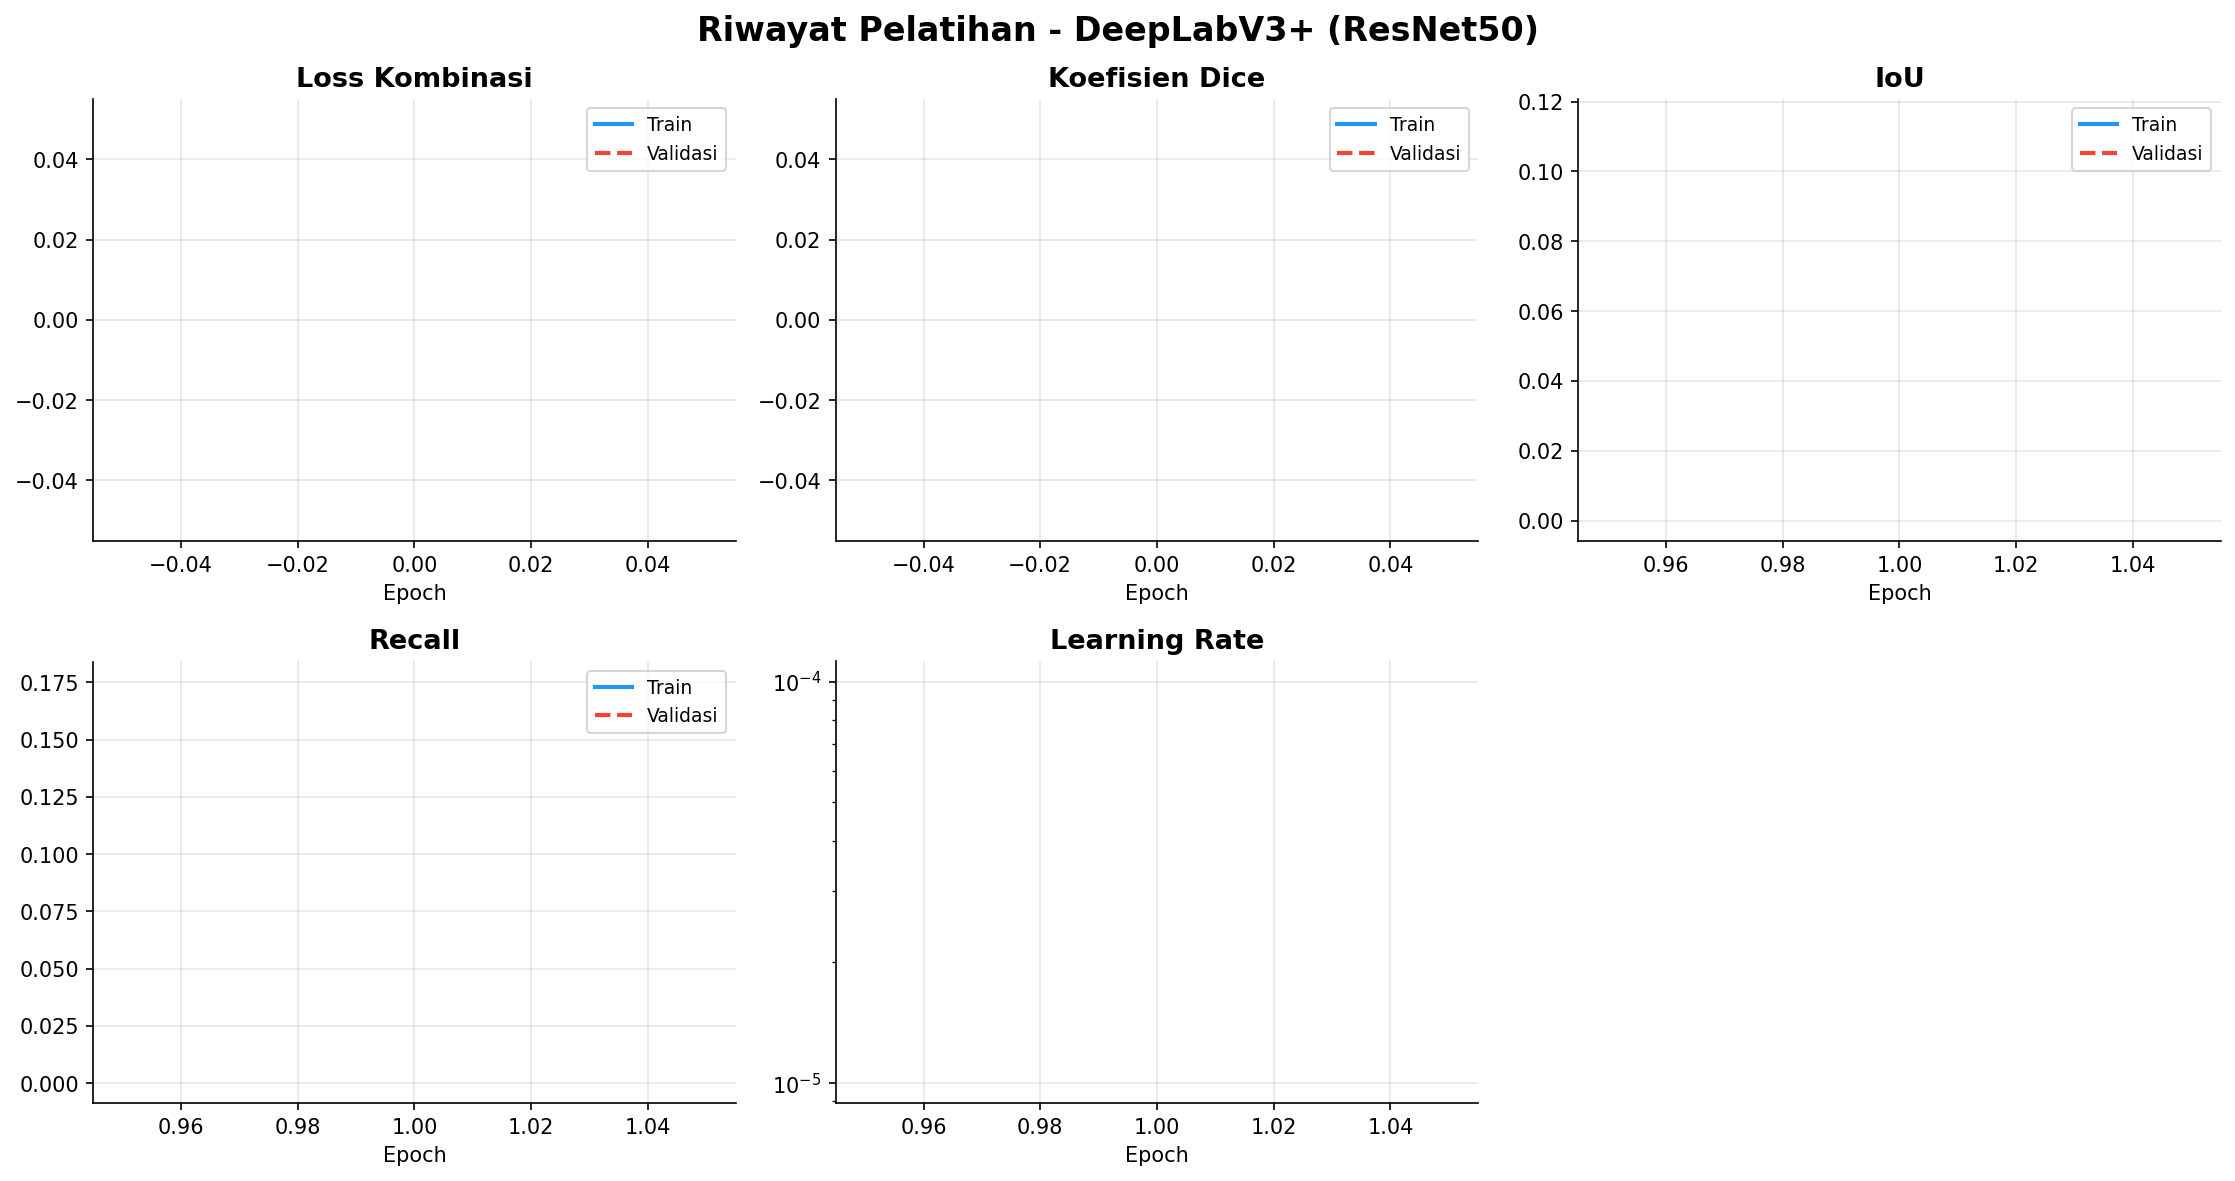

In [9]:
from IPython.display import Image, display
if history is not None:
    boundary = FREEZE_BACKBONE_EPOCHS or None
    plot_history(history, save_dir="plots", phase_boundary=boundary)
    display(Image("plots/05_training_history.png"))
elif os.path.exists(CSV_PATH):
    plot_history_from_csv(CSV_PATH, save_dir="plots")
    display(Image("plots/05_training_history.png"))
else:
    print("Belum ada riwayat yang bisa diplot.")